Time column is increasing: True
Missing values:
0_x     0
13_x    0
14_x    0
17_x    0
37_x    0
0_y     0
13_y    0
14_y    0
17_y    0
37_y    0
dtype: int64


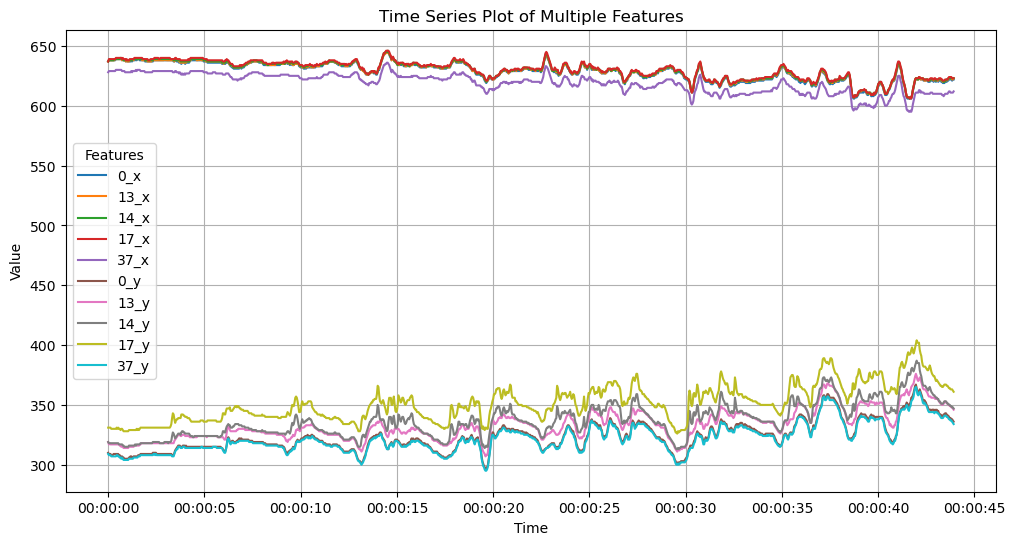

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Veri Setini Yükleme
file_path = "data/selected_lip_coordinates.csv"
df = pd.read_csv(file_path)

# 'time' sütununu tarih veya zaman olarak kullanmak
df['time'] = pd.to_datetime(df['time'], unit='s')  # Eğer zaman saniye cinsindense unit='s' ekleyebilirsiniz
df.set_index("time", inplace=True)

# 2. Zaman Serisi Doğrulama
print("Time column is increasing:", df.index.is_monotonic_increasing)
print("Missing values:")
print(df.isnull().sum())

# Zaman bilgisini x ekseni olarak belirle
time = df.index

# 3. Zaman Serisi Görselleştirme
plt.figure(figsize=(12, 6))

# Her sütunu ayrı ayrı çiz
for col in df.columns:
    plt.plot(time, df[col], label=col)

# Grafik ayarları
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot of Multiple Features")
plt.legend(title="Features")
plt.grid(True)
plt.show()
plt.close()

In [7]:
# 4. ADF Durağanlık Testi ve Durağan Olmayanlara Fark Alma
def adf_test(series):
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    if result[1] <= 0.05:
        print("Seri durağandır.")
        return True
    else:
        print("Seri durağan değildir.")
        return False

print("Durağanlık Testi Sonuçları:")
non_stationary_columns = []
for column in df.columns:
    print(f"\n{column} için ADF Testi:")
    is_stationary = adf_test(df[column])
    if not is_stationary:
        non_stationary_columns.append(column)

print(f"Durağan olmayan sütunlar: {non_stationary_columns}")

Durağanlık Testi Sonuçları:

0_x için ADF Testi:
ADF Statistic: -2.1645442528685397
p-value: 0.2193645005987338
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

13_x için ADF Testi:
ADF Statistic: -2.2034393172168696
p-value: 0.2049995521218611
Critical Values:
   1%: -3.436419361753321
   5%: -2.864219865461312
   10%: -2.5681968527091907
Seri durağan değildir.

14_x için ADF Testi:
ADF Statistic: -2.1719662865125042
p-value: 0.21657691926162198
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağan değildir.

17_x için ADF Testi:
ADF Statistic: -2.2470378244052447
p-value: 0.18961826581672053
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061954
   10%: -2.5681942108302214
Seri durağan değildir.

37_x için ADF Testi:
ADF Statistic: -2.1981466674290706
p-value: 0.2069187972105
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061

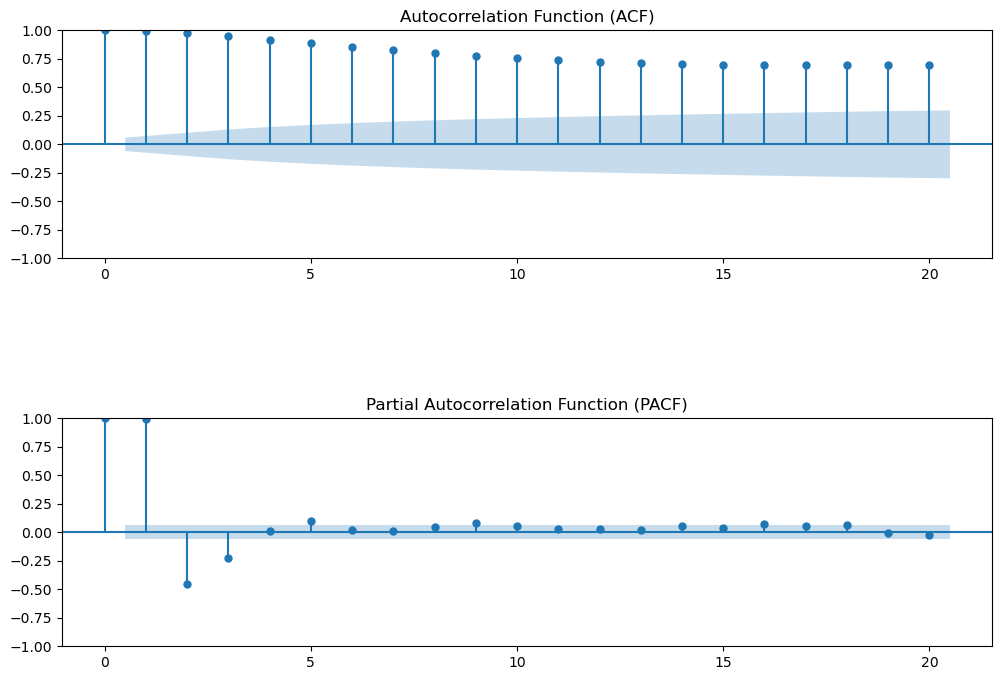

In [22]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [23]:
# 1. Dereceden fark alma (Sadece durağan olmayan sütunlara)

df_diff = df.copy()
df_diff[non_stationary_columns] = df[non_stationary_columns].diff()

print(df_diff.shape)

# Fark alınmış veri için ADF testi uygulama
print("Fark Alınmış Veriler İçin ADF Testi Sonuçları:")
non_stationary_columns_after_diff = []
for column in non_stationary_columns:  # Sadece fark alınan sütunları test et
    print(f"\n{column} için ADF Testi (Fark Alınmış):")
    is_stationary = adf_test(df_diff[column])
    if not is_stationary:
        non_stationary_columns_after_diff.append(column)

if non_stationary_columns_after_diff:
    print("\nHala durağan olmayan sütunlar:", non_stationary_columns_after_diff)
else:
    print("\nTüm seriler fark alma işlemi sonrası durağan hale geldi.")

(1099, 10)
Fark Alınmış Veriler İçin ADF Testi Sonuçları:

0_x için ADF Testi (Fark Alınmış):
ADF Statistic: -11.978892038028363
p-value: 3.745100821121786e-22
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağandır.

13_x için ADF Testi (Fark Alınmış):
ADF Statistic: -10.839580883103736
p-value: 1.6288501133385358e-19
Critical Values:
   1%: -3.436419361753321
   5%: -2.864219865461312
   10%: -2.5681968527091907
Seri durağandır.

14_x için ADF Testi (Fark Alınmış):
ADF Statistic: -12.067360196902184
p-value: 2.391518856341502e-22
Critical Values:
   1%: -3.4364137337554785
   5%: -2.864217382986235
   10%: -2.568195530545688
Seri durağandır.

17_x için ADF Testi (Fark Alınmış):
ADF Statistic: -12.451624792695563
p-value: 3.564805910267353e-23
Critical Values:
   1%: -3.4364081161854747
   5%: -2.8642149051061954
   10%: -2.5681942108302214
Seri durağandır.

37_x için ADF Testi (Fark Alınmış):
ADF Statistic: -11.951367814628702


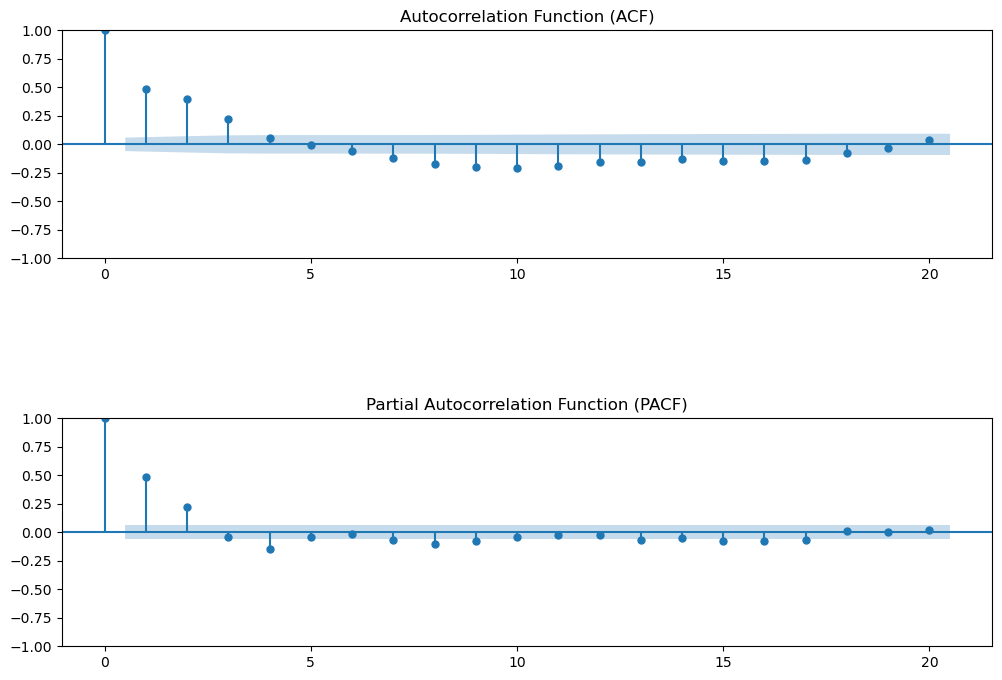

In [24]:
# 5. ACF ve PACF Grafikleri
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(df_diff.dropna().iloc[:, 0], ax=ax[0], lags=20)
ax[0].set_title("Autocorrelation Function (ACF)")
plot_pacf(df_diff.dropna().iloc[:, 0], ax=ax[1], lags=20)
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.subplots_adjust(hspace=0.7, wspace=0.4)
plt.show()

In [50]:
# 'time' sütununu çıkararak sadece değişkenleri seç
data = df.astype("float64")

# Tahminleri saklamak için boş liste
rolling_forecast = []

# VAR modelini fark alınmış verilerle eğit
var_model = VAR(df_diff)
var_model_fit = var_model.fit(maxlags=1)

# Modelin gerektirdiği gecikme sayısını öğren
lags = var_model_fit.k_ar

# Geçmiş veriyi başlat (ilk 'lags' gözlemi kullanarak)
history = df_diff.values[:lags]

# Tüm zaman adımları için kaydırmalı tahmin yap
for t in range(lags, len(df_diff)):
    # Bir adım tahmin yap (Son 'lags' gözlemi kullanarak)
    yhat = var_model_fit.forecast(y=history[-lags:], steps=1)
    
    # Tahmini kaydet
    rolling_forecast.append(yhat[0])
    
    # Gerçek değeri ekleyerek veri setini güncelle
    history = np.vstack([history, df_diff.iloc[t].values])

# Tahminleri DataFrame formatına çevir
rolling_forecast_df = pd.DataFrame(rolling_forecast, columns=df_diff.columns)

# Farklıktan orijinal ölçeğe dönüştürme
last_real_values = data.iloc[lags-1].copy()
rolling_forecast_original = []
for diff_forecast in rolling_forecast_df.values:
    last_real_values = last_real_values + diff_forecast
    rolling_forecast_original.append(last_real_values.copy())

rolling_forecast_original_df = pd.DataFrame(rolling_forecast_original, columns=data.columns)

# Gerçek ve tahmin edilen değerleri birleştirmek için DataFrame oluştur
comparison_df = data.iloc[lags+1:].reset_index(drop=True).copy()  # Gerçek değerler
rolling_forecast_original_df = rolling_forecast_original_df.reset_index(drop=True)  # Tahmin edilen değerler

# Gerçek ve tahmin edilen değerleri yanyana birleştir
for col in data.columns:
    comparison_df[f"{col}_pred"] = rolling_forecast_original_df[col]

# Hata metrikleri hesaplama
mae_values = {col: mean_absolute_error(comparison_df[col], comparison_df[f"{col}_pred"]) for col in data.columns}
mse_values = {col: mean_squared_error(comparison_df[col], comparison_df[f"{col}_pred"]) for col in data.columns}
rmse_values = {col: np.sqrt(mse_values[col]) for col in data.columns}
mape_values = {col: np.mean(np.abs((comparison_df[col] - comparison_df[f"{col}_pred"]) / comparison_df[col])) * 100 for col in data.columns}

# Hata metriklerini DataFrame'e çevir
error_metrics_df = pd.DataFrame({
    "Feature": data.columns,
    "MAE": mae_values.values(),
    "MSE": mse_values.values(),
    "RMSE": rmse_values.values(),
    "MAPE": mape_values.values()
})

# Sonuçları ekranda göster
print("Gerçek vs Tahmin Edilen Değerler:")
print(comparison_df)
print("------------------------------------------------------------------------------")
print("\nHata Metrikleri (MAE, MSE, RMSE, MAPE):")
print(error_metrics_df)

C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 40ms will be used.
  self._init_dates(dates, freq)


Gerçek vs Tahmin Edilen Değerler:
        0_x   13_x   14_x   17_x   37_x    0_y   13_y   14_y   17_y   37_y  \
0     638.0  638.0  639.0  639.0  629.0  309.0  318.0  318.0  331.0  308.0   
1     638.0  638.0  638.0  639.0  629.0  309.0  317.0  318.0  331.0  308.0   
2     638.0  638.0  638.0  639.0  629.0  308.0  317.0  318.0  330.0  307.0   
3     638.0  638.0  638.0  639.0  629.0  308.0  317.0  318.0  330.0  307.0   
4     638.0  638.0  638.0  639.0  629.0  308.0  317.0  318.0  330.0  307.0   
...     ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
1092  622.0  623.0  623.0  624.0  611.0  339.0  349.0  349.0  363.0  337.0   
1093  622.0  623.0  623.0  624.0  611.0  338.0  348.0  349.0  363.0  337.0   
1094  621.0  622.0  623.0  623.0  611.0  338.0  348.0  348.0  363.0  336.0   
1095  622.0  622.0  623.0  623.0  611.0  337.0  347.0  348.0  362.0  335.0   
1096  622.0  623.0  623.0  623.0  612.0  336.0  346.0  347.0  361.0  334.0   

        0_x_pred   13_x_pred 